In [195]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor

sales = pd.read_csv(r"D:\Datathon\data\sales.csv")
web = pd.read_csv(r"D:\Datathon\data\web_traffic.csv")
inventory = pd.read_csv(r"D:\Datathon\data\inventory.csv")

sales['Date'] = pd.to_datetime(sales['Date'])
web['date'] = pd.to_datetime(web['date'])
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])

df = sales.merge(web, left_on='Date', right_on='date', how='left')
df.drop(columns=['date'], inplace=True)

inv = inventory.groupby('snapshot_date').agg({
    'stock_on_hand': 'sum',
    'stockout_flag': 'sum'
}).reset_index()

df = df.merge(inv, left_on='Date', right_on='snapshot_date', how='left')
df[['stock_on_hand','stockout_flag']] = df[['stock_on_hand','stockout_flag']].ffill()
df.drop(columns=['snapshot_date'], inplace=True)

df = df.sort_values('Date')

In [196]:
df['dayofweek'] = df['Date'].dt.dayofweek
df['month'] = df['Date'].dt.month
df['weekofyear'] = df['Date'].dt.isocalendar().week.astype(int)
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

df['dayofyear'] = df['Date'].dt.dayofyear
df['sin_year'] = np.sin(2*np.pi*df['dayofyear']/365)
df['cos_year'] = np.cos(2*np.pi*df['dayofyear']/365)

df['sin_week'] = np.sin(2*np.pi*df['dayofweek']/7)
df['cos_week'] = np.cos(2*np.pi*df['dayofweek']/7)

df['trend'] = np.arange(len(df))

In [197]:
lags = [1,2,3,7,14,21,30,60,365]

for lag in lags:
    df[f'lag_{lag}'] = df['Revenue'].shift(lag)

In [198]:
df['rolling_mean_7'] = df['Revenue'].shift(1).rolling(7).mean()
df['rolling_mean_30'] = df['Revenue'].shift(1).rolling(30).mean()

df['rolling_std_7'] = df['Revenue'].shift(1).rolling(7).std()
df['rolling_std_30'] = df['Revenue'].shift(1).rolling(30).std()

df['rolling_max_7'] = df['Revenue'].shift(1).rolling(7).max()
df['rolling_min_7'] = df['Revenue'].shift(1).rolling(7).min()

In [199]:
threshold = df['Revenue'].quantile(0.9)

df['is_spike'] = (df['Revenue'] > threshold).astype(int)

df['lag_spike_7'] = df['is_spike'].shift(7)
df['lag_spike_14'] = df['is_spike'].shift(14)
df['lag_spike_30'] = df['is_spike'].shift(30)

df['rolling_spike_7'] = df['is_spike'].shift(1).rolling(7).mean()

df['sessions_lag_1'] = df['sessions'].shift(1)
df['sessions_rolling_7'] = df['sessions'].shift(1).rolling(7).mean()
df['sessions_diff'] = df['sessions'].diff()

In [200]:
df['diff_1'] = df['Revenue'].diff()
df['diff_7'] = df['Revenue'].diff(7)

df['weekend_x_sessions'] = df['is_weekend'] * df['sessions']

df['last_year'] = df['Revenue'].shift(365)

df = df.dropna()

In [201]:
features = [c for c in df.columns if c not in ['Date','Revenue', 'traffic_source']]

In [202]:
model = LGBMRegressor(
    n_estimators=4000,
    learning_rate=0.005,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(df[features], df['Revenue'])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001534 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8439
[LightGBM] [Info] Number of data points in the train set: 3468, number of used features: 45
[LightGBM] [Info] Start training from score 4243512.116196


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.005
,n_estimators,4000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [203]:
last_year_sessions = df['sessions'].iloc[-365:].values

future_sessions = np.tile(last_year_sessions, 2)[:len(test_dates)]

In [204]:
test_dates = pd.date_range(start='2023-01-01', end='2024-07-01')

history = df.copy()
preds = []

for i, date in enumerate(test_dates):

    row = {}

    # time
    row['dayofweek'] = date.dayofweek
    row['month'] = date.month
    row['weekofyear'] = date.isocalendar().week
    row['is_weekend'] = int(date.dayofweek >= 5)

    row['dayofyear'] = date.dayofyear
    row['sin_year'] = np.sin(2*np.pi*date.dayofyear/365)
    row['cos_year'] = np.cos(2*np.pi*date.dayofyear/365)

    row['sin_week'] = np.sin(2*np.pi*date.dayofweek/7)
    row['cos_week'] = np.cos(2*np.pi*date.dayofweek/7)

    row['trend'] = len(history)

    # lag
    for lag in lags:
        row[f'lag_{lag}'] = history['Revenue'].iloc[-lag]

    # rolling
    rev = history['Revenue'].values
    row['rolling_mean_7'] = rev[-7:].mean()
    row['rolling_mean_30'] = rev[-30:].mean()
    row['rolling_std_7'] = rev[-7:].std()
    row['rolling_std_30'] = rev[-30:].std()
    row['rolling_max_7'] = rev[-7:].max()
    row['rolling_min_7'] = rev[-7:].min()

    # spike features
    threshold = history['Revenue'].quantile(0.9)
    row['is_spike'] = int(rev[-1] > threshold)
    row['lag_spike_7'] = history['is_spike'].iloc[-7]
    row['lag_spike_14'] = history['is_spike'].iloc[-14]
    row['lag_spike_30'] = history['is_spike'].iloc[-30]
    row['rolling_spike_7'] = history['is_spike'].iloc[-7:].mean()

    # traffic
    row['sessions'] = future_sessions[i]
    row['sessions_lag_1'] = history['sessions'].iloc[-1]
    row['sessions_rolling_7'] = history['sessions'].iloc[-7:].mean()
    row['sessions_diff'] = history['sessions'].iloc[-1] - history['sessions'].iloc[-2]

    row['weekend_x_sessions'] = row['is_weekend'] * row['sessions']

    # diff
    row['diff_1'] = rev[-1] - rev[-2]
    row['diff_7'] = rev[-1] - rev[-7]

    # inventory
    row['stock_on_hand'] = history['stock_on_hand'].iloc[-1]
    row['stockout_flag'] = history['stockout_flag'].iloc[-1]

    row['last_year'] = history['Revenue'].iloc[-365]
    
    # Carry forward other external features
    for col in features:
        if col not in row:
            row[col] = history[col].iloc[-1]

    X = pd.DataFrame([row])[features]

    pred_model = model.predict(X)[0]
    pred_last_year = history['Revenue'].iloc[-365]
    pred = 0.6 * pred_model + 0.4 * pred_last_year

    pred = max(pred, 0)

    # spike scaling
    last_year_window = history['Revenue'].iloc[-372:-365]
    ratio = pred_last_year / (last_year_window.mean() + 1)

    pred *= (1 + 0.3 * ratio)

    preds.append(pred)

    # update history
    new_row = row.copy()
    new_row['Revenue'] = pred

    history = pd.concat([history, pd.DataFrame([new_row])], ignore_index=True)

In [205]:
submission = pd.read_csv("D:\Datathon\data\sample_submission.csv")
submission['Revenue'] = preds

submission.to_csv("submission.csv", index=False)


<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_14884\3346998169.py:1: SyntaxWarning: invalid escape sequence '\D'
  submission = pd.read_csv("D:\Datathon\data\sample_submission.csv")


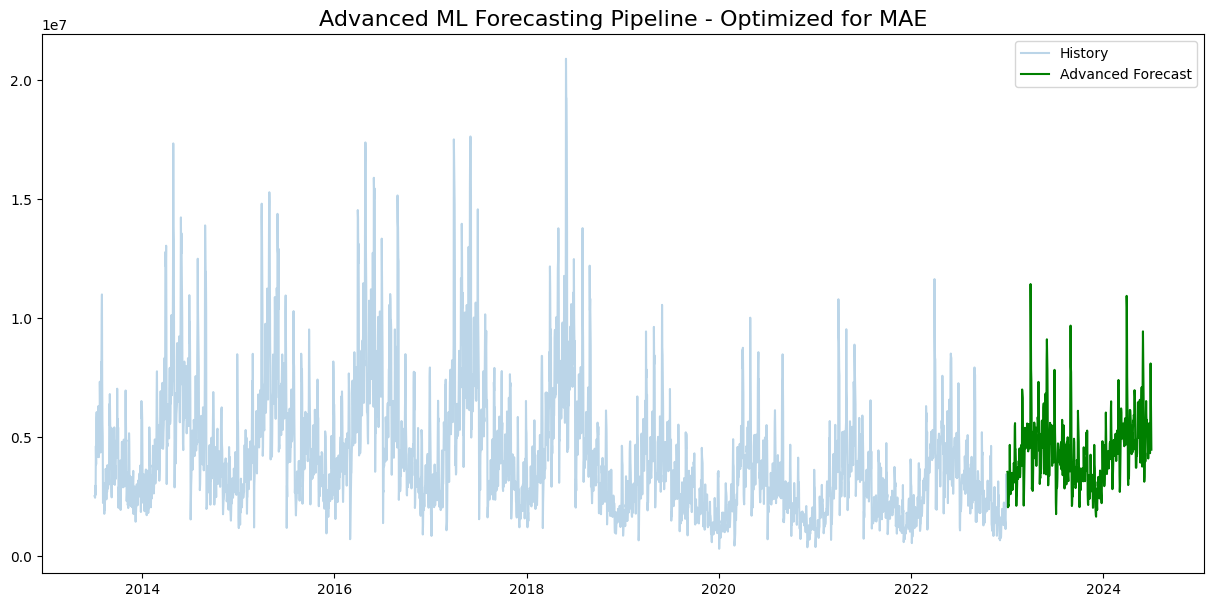

In [206]:
import matplotlib.pyplot as plt

submission['Date'] = pd.to_datetime(submission['Date'])
plt.figure(figsize=(15, 7))
plt.plot(df['Date'], df['Revenue'], label='History', alpha=0.3)
plt.plot(submission['Date'], submission['Revenue'], label='Advanced Forecast', color='green')
plt.title('Advanced ML Forecasting Pipeline - Optimized for MAE', fontsize=16)
plt.legend()
plt.show()

                     feature  importance
0                       COGS       25600
41                    diff_1       18932
18                     lag_1       17352
42                    diff_7       13678
26                   lag_365       10579
13                  sin_year        8286
24                    lag_30        8286
21                     lag_7        8260
40             sessions_diff        7957
14                  cos_year        7841
25                    lag_60        7395
4                bounce_rate        6420
5   avg_session_duration_sec        6326
20                     lag_3        6144
19                     lag_2        6070
7              stockout_flag        5629
12                 dayofyear        5530
23                    lag_21        5491
27            rolling_mean_7        5427
30            rolling_std_30        5401


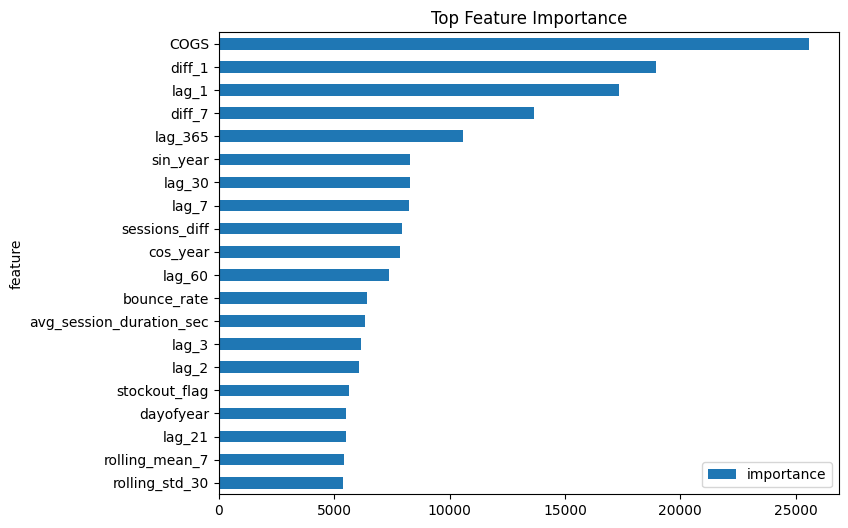

In [207]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.DataFrame({
    'feature': model.feature_name_,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance.head(20))

importance.head(20).plot(
    kind='barh',
    x='feature',
    y='importance',
    figsize=(8,6)
)
plt.gca().invert_yaxis()
plt.title("Top Feature Importance")
plt.show()

In [208]:
import shap

explainer = shap.TreeExplainer(model)

# sample 200 dòng để nhanh
X_sample = df[features].sample(200, random_state=42)

shap_values = explainer.shap_values(X_sample)

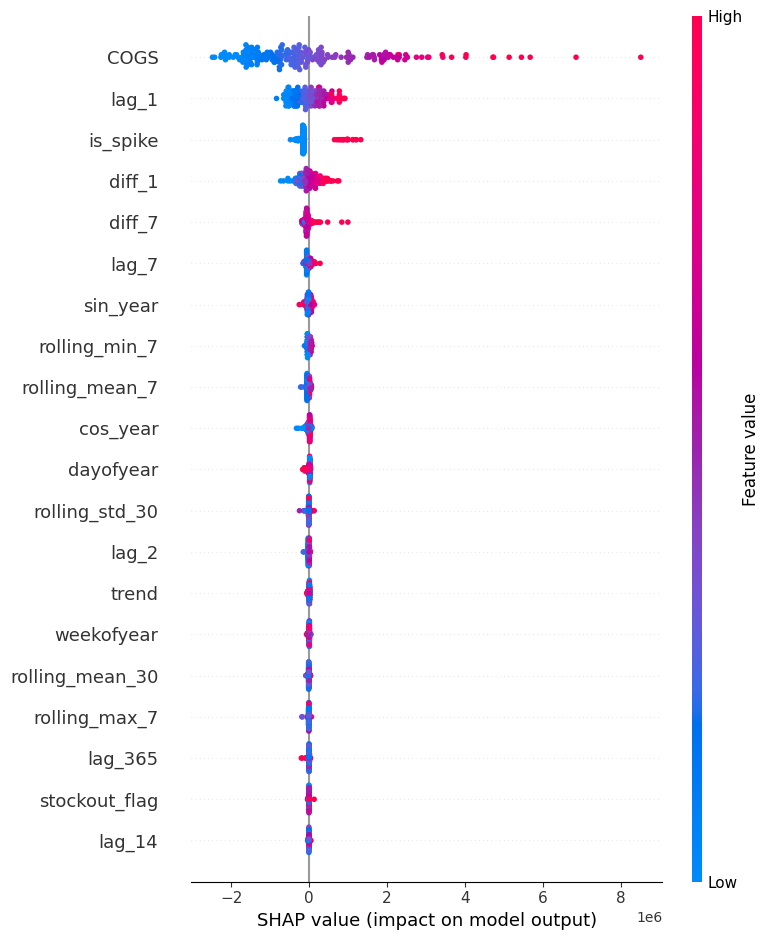

In [209]:
shap.summary_plot(shap_values, X_sample)

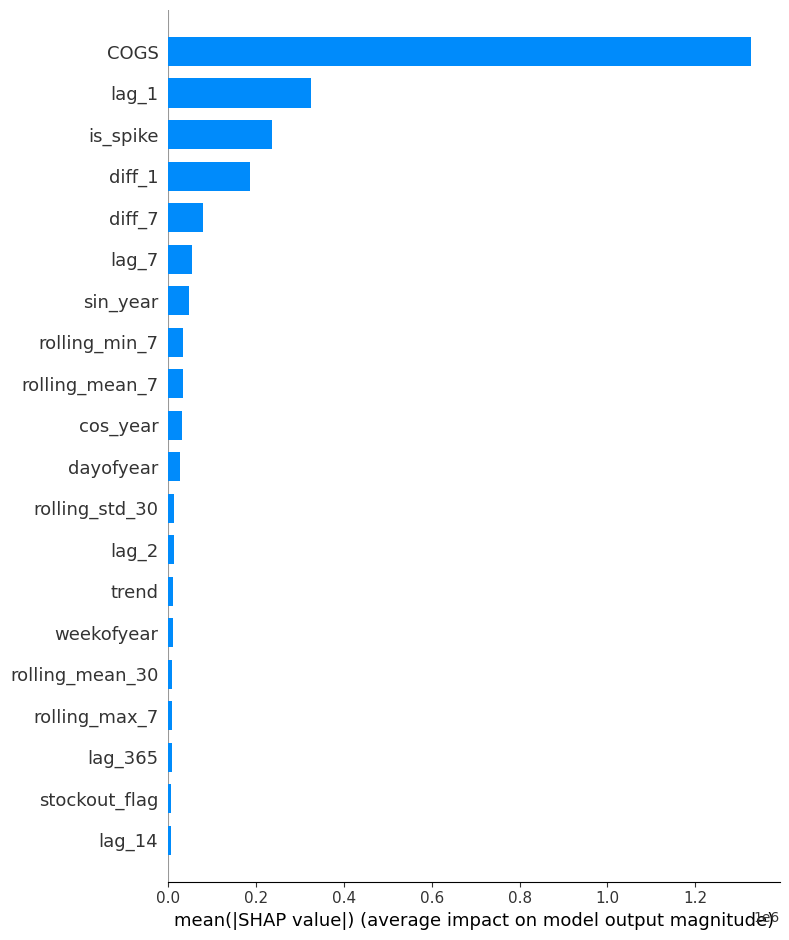

In [210]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")